## EDA

In [1]:
from scipy import stats
from pathlib import Path

import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow as pa



In [2]:
DATA_DIR = Path.cwd().resolve().parent / 'data'
DATA_DIR

WindowsPath('C:/Users/usuario/Desktop/Proyecto-Mlops/data')

In [3]:
df_data = pd.read_parquet(DATA_DIR / '01_data_suicidios.parquet')

#visualizacion de los datos
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   NombreMunicipio          2500 non-null   str  
 1   NombreRegion             2500 non-null   str  
 2   Anio                     2500 non-null   int64
 3   CausaMortalidad          2500 non-null   str  
 4   TipoPoblacionObjetivo    2500 non-null   str  
 5   NumeroPoblacionObjetivo  2500 non-null   str  
 6   NumeroCasos              2500 non-null   int64
dtypes: int64(2), str(5)
memory usage: 252.4 KB


In [4]:
print('Dimensiones:',df_data.shape)

Dimensiones: (2500, 7)


In [5]:
print('Tipos de datos:')
df_data.dtypes

Tipos de datos:


NombreMunicipio              str
NombreRegion                 str
Anio                       int64
CausaMortalidad              str
TipoPoblacionObjetivo        str
NumeroPoblacionObjetivo      str
NumeroCasos                int64
dtype: object

In [6]:
df_data.isnull().sum(skipna=False)

NombreMunicipio            0
NombreRegion               0
Anio                       0
CausaMortalidad            0
TipoPoblacionObjetivo      0
NumeroPoblacionObjetivo    0
NumeroCasos                0
dtype: int64

In [7]:
print('cantidad de duplicados:',df_data.duplicated().sum())

cantidad de duplicados: 0


## Conversion de datos

In [8]:
cols_categoricas = ['NombreMunicipio','NombreRegion']
df_data[cols_categoricas] = df_data[cols_categoricas].astype('category')


In [9]:
#variables numericas
df_data['NumeroPoblacionObjetivo'] = (
    df_data['NumeroPoblacionObjetivo']
    .astype(str)
    .str.replace(',', '', regex=False)
)
df_data['NumeroPoblacionObjetivo'] = pd.to_numeric(df_data['NumeroPoblacionObjetivo'],errors='coerce').astype('float64')

df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   NombreMunicipio          2500 non-null   category
 1   NombreRegion             2500 non-null   category
 2   Anio                     2500 non-null   int64   
 3   CausaMortalidad          2500 non-null   str     
 4   TipoPoblacionObjetivo    2500 non-null   str     
 5   NumeroPoblacionObjetivo  2500 non-null   float64 
 6   NumeroCasos              2500 non-null   int64   
dtypes: category(2), float64(1), int64(2), str(2)
memory usage: 163.5 KB


In [10]:
df_data.head()

,NombreMunicipio,NombreRegion,Anio,CausaMortalidad,TipoPoblacionObjetivo,NumeroPoblacionObjetivo,NumeroCasos
0,Abejorral,ORIENTE,2005,Suicidios,Poblacion total,20249.0,2
1,Abriaquí,OCCIDENTE,2005,Suicidios,Poblacion total,2690.0,0
2,Alejandría,ORIENTE,2005,Suicidios,Poblacion total,3816.0,0
3,Amagá,SUROESTE,2005,Suicidios,Poblacion total,27155.0,0
4,Amalfi,NORDESTE,2005,Suicidios,Poblacion total,20525.0,2


## Creacion de tablas 

### Conociendo los municipios

In [11]:
pivot_table = pd.pivot_table(df_data, values='NumeroCasos', index='NombreMunicipio',columns='Anio', aggfunc='sum')
pivot_table

Anio,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
NombreMunicipio,,,,,,,,,,,,,,,,,,,,
Abejorral,2,1,4,3,2,0,1,2,1,1,2,2,1,4,0,1,1,3,1,4
Abriaquí,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Alejandría,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
Amagá,0,3,0,1,3,0,3,2,3,3,3,3,1,3,4,1,0,1,5,0
Amalfi,2,1,3,0,5,5,0,0,2,2,2,0,1,1,2,1,2,2,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yalí,0,3,2,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
Yarumal,2,3,2,0,3,3,3,2,0,3,3,5,4,4,2,3,2,4,6,12
Yolombó,3,0,0,2,1,2,1,1,2,0,0,0,0,2,2,3,6,1,4,1


### Casos por Años

In [12]:
total_casos = df_data.groupby('Anio')['NumeroCasos'].sum()
print(total_casos)

Anio
2005    327
2006    328
2007    296
2008    338
2009    335
2010    326
2011    325
2012    329
2013    330
2014    323
2015    374
2016    400
2017    392
2018    434
2019    476
2020    453
2021    488
2022    541
2023    586
2024    515
Name: NumeroCasos, dtype: int64


In [13]:
df_total_casos = total_casos.to_frame(name='Total')
df_total_casos = df_total_casos.reset_index()

total_suma= df_total_casos['Total'].sum()
df_total_casos['Porcentaje'] = (df_total_casos['Total'] /total_suma)*100
df_total_casos['Porcentaje'] = df_total_casos['Porcentaje'].round(2)

#visualizacion de la tabla
print(df_total_casos)

    Anio  Total  Porcentaje
0   2005    327        4.13
1   2006    328        4.14
2   2007    296        3.74
3   2008    338        4.27
4   2009    335        4.23
5   2010    326        4.12
6   2011    325        4.11
7   2012    329        4.16
8   2013    330        4.17
9   2014    323        4.08
10  2015    374        4.72
11  2016    400        5.05
12  2017    392        4.95
13  2018    434        5.48
14  2019    476        6.01
15  2020    453        5.72
16  2021    488        6.16
17  2022    541        6.83
18  2023    586        7.40
19  2024    515        6.51


### Identificando las regiones

In [14]:
pivot_table_region = pd.pivot_table(df_data, values='NumeroCasos', index='NombreRegion', columns='Anio', aggfunc='sum')
pivot_table_region

Anio,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
NombreRegion,,,,,,,,,,,,,,,,,,,,
BAJO CAUCA,8,11,10,12,8,6,4,7,13,18,15,10,13,11,11,6,13,13,8,9
MAGDALENA MEDIO,10,7,5,4,4,5,5,9,10,7,5,5,8,7,7,7,4,11,2,4
NORDESTE,11,19,18,13,13,23,8,10,12,11,11,10,15,9,13,15,18,6,23,9
NORTE,17,17,19,13,20,15,19,16,15,18,15,21,25,21,20,13,15,24,16,33
OCCIDENTE,9,11,9,11,14,9,8,13,5,10,10,13,14,18,17,16,20,11,21,18
ORIENTE,31,27,43,41,42,42,38,37,39,50,38,45,44,53,57,55,55,72,68,71
SUROESTE,29,46,22,34,32,23,37,31,20,21,32,24,25,30,21,34,33,33,24,22
URABA,19,16,11,12,14,13,19,19,14,16,21,22,12,29,26,29,29,28,34,38
VALLE DE ABURRA,193,174,159,198,188,190,187,187,202,172,227,250,236,256,304,278,301,343,390,311


## Correlacion

In [ ]:
# Seleccionamos variables numéricas
vars_numericas = ['NumeroCasos', 'Anio','NumeroPoblacionObjetivo']

# Prueba de Normalidad
stat, p_anios = stats.normaltest(df_data['Anio'])
stat, p_numeroCasos = stats.normaltest(df_data['NumeroCasos'])
stat, p_numeroPoblacion = stats.normaltest(df_data['NumeroPoblacionObjetivo'])

print("\n--- Justificación de Correlación ---")
print(f"P-valor Edad: {p_anios:.5f}")
print(f"P-valor numero de casos: {p_numeroCasos:.5f}")
print(f"P-valor numero poblacion objetivo:{p_numeroPoblacion:.5f}")
# Decisión
metodo = 'pearson' if (p_anios > 0.05 and p_numeroCasos > 0.05) else 'spearman'
print(f"Decisión: Se utilizará {metodo.capitalize()} porque el p-valor < 0.05 indica que los datos NO siguen una distribución normal.")




--- Justificación de Correlación ---
P-valor Edad: 0.00000
P-valor numero de casos: 0.00000
P-valor numero poblacion objetivo:0.00000
Decisión: Se utilizará Spearman porque el p-valor < 0.05 indica que los datos NO siguen una distribución normal.


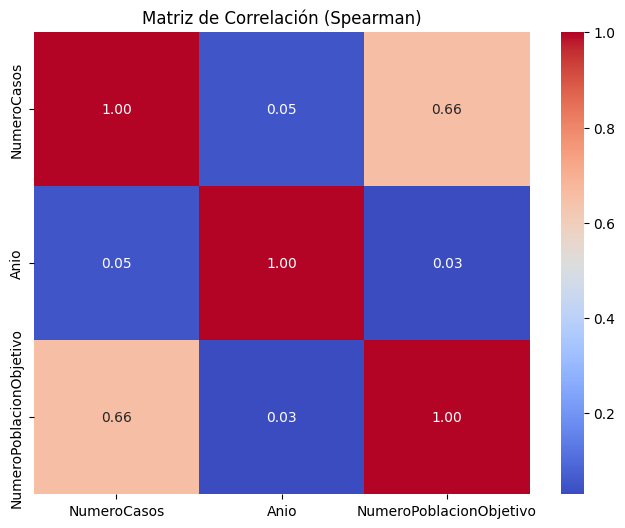

In [16]:
# Matriz de Correlación
corr_matrix = df_data[vars_numericas].corr(method=metodo)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Matriz de Correlación ({metodo.capitalize()})')
plt.show()

## Figuras y Graficos

In [22]:
fig = px.bar(df_total_casos, 
             x='Total', 
             y='Anio',
             orientation='h',
             text='Porcentaje',
             title='Distribucion de suicidio por años'
             )

fig.show()